In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dataset = pd.read_csv("./dataset_ml_final.csv")
dataset

,Sentiment,comment
0,2,به هیچ‌ وجه قصد توهین و بی ادبی ندارم ولی مشخص...
1,5,الان 1 سال هست که از این شارژر هر روز استفاده...
2,4,امروز از دیجی در تخفیف خریدم ، اول که زیپش را ...
3,3,این گوشی از لحاظ ساخت با اس 8 فرق زیادی نداره ...
4,4,درود\nمن یک تصادف جزئی داشتم که قسمتی از سپر ک...
...,...,...
9532,2,بوی بد پدسلولزی افتضاحه .اولی رو از دی جی کالا...
9533,3,من امروز این محصول بدستم رسید. همه چیش خوب بود...
9534,4,سطل زباله معمولا تو سرویس از بقیه زودتر خراب م...
9535,5,اول این که این محصول بسته بندی تمیز و مرتبی دا...


# Statistical Analysis

In [ ]:
dict(dataset["Sentiment"].value_counts())

{5: 3186, 4: 2178, 2: 1726, 3: 1331, 1: 1116}

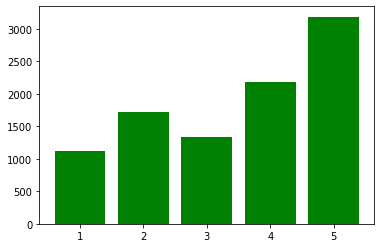

In [ ]:
plt.bar(dict(dataset["Sentiment"].value_counts()).keys(), dict(dataset["Sentiment"].value_counts()).values(), color='g')
plt.show()

In [ ]:
dataset["Sentiment"].value_counts().mean()

1907.4

# Create Balanced Dataset

In [ ]:
sample_label_1 = dataset[dataset['Sentiment']==1].sample(n=int(dataset["Sentiment"].value_counts().mean()), replace=True)
# sample_label_1 = dataset[dataset['Sentiment']==1].sample(n=int(dataset["Sentiment"].value_counts().mean()) if \
#                                                          len(dataset[dataset['Sentiment']==1]) < int(dataset["Sentiment"].value_counts().mean()) else \
#                                                          len(dataset[dataset['Sentiment']==1]))


sample_label_2 = dataset[dataset['Sentiment']==2].sample(n=int(dataset["Sentiment"].value_counts().mean()), replace=True)
sample_label_3 = dataset[dataset['Sentiment']==3].sample(n=int(dataset["Sentiment"].value_counts().mean()), replace=True)
sample_label_4 = dataset[dataset['Sentiment']==4].sample(n=int(dataset["Sentiment"].value_counts().mean()))
sample_label_5 = dataset[dataset['Sentiment']==5].sample(n=int(dataset["Sentiment"].value_counts().mean()))

In [ ]:
dataset_balanced = pd.concat([sample_label_1,sample_label_2,sample_label_3,sample_label_4,sample_label_5])
dataset_balanced

,Sentiment,comment
6081,1,اینجور بگو... افتضاح ترین کرمی بود که به پوستم...
6168,1,بدترین کاور
2395,1,من هیچگونه اطلاعات فنی از ابزار و جعبه ابزار و...
6206,1,خیلی بی کیفیت
183,1,این مارک به درد نمی خوره
...,...,...
398,5,من بیش از 2 ماهه که خریدم و در این مدت واقعا ا...
4939,5,کیفیت عالی
4713,5,در کل عالی
489,5,من از خریدم راضیم.\nچون هم کارایی بالایی داره\...


In [ ]:
dataset_balanced['Sentiment'].value_counts()

1    1907
2    1907
3    1907
4    1907
5    1907
Name: Sentiment, dtype: int64

In [ ]:
from sklearn.utils import shuffle
dataset_balanced = shuffle(dataset_balanced)
dataset_balanced

,Sentiment,comment
9357,3,سلام من این کیفو حدود دوهفته پیش از دیجی کالا ...
5904,1,خشک و بی مصرف
9129,3,گریل اش من هرچی میذارم توش آبش جمع میشه و اب پ...
7752,1,خوب نیست EndOfTitle خیلی بی کیفیته قطعات زیاد ...
1053,1,مشتری مداری صفر
...,...,...
4702,5,عالیییی....
327,4,در مجموع بنده حدود هفت ماه است که از شگفت انگی...
8235,2,تاخیر تحویل EndOfTitle بنظر میرسد که زمان تحوی...
8543,2,من دو دست خریدم. بسته بندی نامناسبی داشت، چند ...


# Preprocessing

In [ ]:
def _multiple_replace(mapping, text):
    pattern = "|".join(map(re.escape, mapping.keys()))
    return re.sub(pattern, lambda m: mapping[m.group()], str(text))

In [ ]:
def convert_fa_numbers(input_str):
    mapping = {
        '۰': '0',
        '۱': '1',
        '۲': '2',
        '۳': '3',
        '۴': '4',
        '۵': '5',
        '۶': '6',
        '۷': '7',
        '۸': '8',
        '۹': '9',
        '.': '.',
    }
    return _multiple_replace(mapping, input_str)

In [ ]:
import string

def remove_special_characters(text):
  chars_to_ignore = [
    ",", "?", ".", "!", "-", ";", ":", '""', "%", "'", '"', "�",
    "#", "!", "؟", "?", "«", "»", "،", "(", ")", "؛", "'ٔ", "٬",'ٔ', ",", "?",
    ".", "!", "-", ";", ":",'"',"“", "%", "‘", "”", "�", "–", "…", "_", "”", '“', '„',
    'ā', 'š',]
  chars_to_ignore = chars_to_ignore + list(string.ascii_lowercase + string.digits)
  chars_to_ignore_regex = f"""[{"".join(chars_to_ignore)}]"""
  text = re.sub(chars_to_ignore_regex, '', text).lower() + " "
  return text

In [ ]:
def convert_special_characters(input_str):
  chars_to_mapping = {
    'ك': 'ک', 'دِ': 'د', 'بِ': 'ب', 'زِ': 'ز', 'ذِ': 'ذ', 'شِ': 'ش', 'سِ': 'س', 'ى': 'ی',
    'ي': 'ی', 'أ': 'ا', 'ؤ': 'و', "ے": "ی", "ۀ": "ه", "ﭘ": "پ", "ﮐ": "ک", "ﯽ": "ی",
    "ﺎ": "ا", "ﺑ": "ب", "ﺘ": "ت", "ﺧ": "خ", "ﺩ": "د", "ﺱ": "س", "ﻀ": "ض", "ﻌ": "ع",
    "ﻟ": "ل", "ﻡ": "م", "ﻢ": "م", "ﻪ": "ه", "ﻮ": "و", 'ﺍ': "ا", 'ة': "ه",
    'ﯾ': "ی", 'ﯿ': "ی", 'ﺒ': "ب", 'ﺖ': "ت", 'ﺪ': "د", 'ﺮ': "ر", 'ﺴ': "س", 'ﺷ': "ش",
    'ﺸ': "ش", 'ﻋ': "ع", 'ﻤ': "م", 'ﻥ': "ن", 'ﻧ': "ن", 'ﻭ': "و", 'ﺭ': "ر", "ﮔ": "گ",
    "a": " ای ", "b": " بی ", "c": " سی ", "d": " دی ", "e": " ایی ", "f": " اف ",
    "g": " جی ", "h": " اچ ", "i": " آی ", "j": " جی ", "k": " کی ", "l": " ال ",
    "m": " ام ", "n": " ان ", "o": " او ", "p": " پی ", "q": " کیو ", "r": " آر ",
    "s": " اس ", "t": " تی ", "u": " یو ", "v": " وی ", "w": " دبلیو ", "x": " اکس ",
    "y": " وای ", "z": " زد ",
    "\u200c": " ", "\u200d": " ", "\u200e": " ", "\u200f": " ", "\ufeff": " ",
    }
  return _multiple_replace(chars_to_mapping, input_str)

In [ ]:
!pip install hazm

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import hazm
_normalizer = hazm.Normalizer()

def preprocess(text):
  text = text.lower().strip()
  text = _normalizer.normalize(text)
  text = re.sub(r'\n', ' ', text)
  text = re.sub(r'[ـ_]', ' ', text)
  text = re.sub(r'[ؤ إ أة ك ء]',' ',text)
  text = re.sub(r'[\s]{2,}', ' ', text) # delete multiple \n \r \t \f \v
  text = re.sub(r'(\w)\1{2,}', r'\1',text) # delete multiple english charecters
  text = re.sub(r'([ٱ-ە])\1{2,}', r'\1',text) # delete multiple persian charecters
  text = remove_special_characters(text)
  text = convert_fa_numbers(text)
  text = convert_special_characters(text)
  return text

In [ ]:
dataset_balanced['comment'] = dataset_balanced['comment'].apply(lambda x: preprocess(x))

In [ ]:
complete_stopwords =(
"""
من
تو
او
ما
شما
آن ها
آنها
آن‌ها
و
یا
پس
اگر
را
چون
چه
تا
که
نیز
الاّ
الی
اندر
با
بر
برای
به
تا
در
من
تو
او
ما
شما
آن ها
آنها
آن‌ها
می
های
ای
اند
تان
مان
ایم
ام
اش
این
آن
اون
اینا
اونا
اینها
اونها
این ها
اون ها
این‌ها
اون‌ها
و
در
به
از
که
را
با
برای
تا
بر
یا
هر
همین
اینکه
این که
چیزی
مگر
آیا
بعضی
شاید
هنوز
قبل
چون
بعد
چند
الان
الآن
فقط
حتی
وقتی
تنها
یعنی
کی
حالا
قبلا
پارسال
هم
هرچی
هر چی
موارد
لااقل
حداقل
روز
همه
همین
دیگه
واقعا
هیچ
بقیه
کل
مختلف
مثلا
درباره
پس
پیش
بالا
پایین
چپ
راست
نزدیک
کنار
بیرون
وسط
بین
داخل
بی زحمت
لطفا
خواهشا
تو رو خدا
وقت
شاید
حالا
سلام
ممنون
مرسی
با تشکر
حدود
تقریبا
در کل
کلا
رو
ازش
راستش
قبلی
بعدی
زیر
روی
در
خب
مقابل
یه
یک
یکی
دو
سه
چهار
پنچ
شش
شیش
هفت
هشت
ده
"""
).split()

In [ ]:
def stopwords_remove(x):
    terms = x.split()
    terms = [w for w in terms if w not in complete_stopwords]
    sentence = ' '.join(terms)
    return sentence

In [ ]:
dataset_balanced['Refined_comment'] = dataset_balanced['comment'].apply(lambda x: stopwords_remove(x))
dataset_balanced

,Sentiment,comment,Refined_comment
9357,3,سلام من این کیفو حدود دوهفته پیش از دیجی کالا ...,کیفو دوهفته دیجی کالا خریدم البته قیمت خیلی کم...
5904,1,خشک و بی مصرف,خشک مصرف
9129,3,گریل اش من هرچی میذارم توش آبش جمع میشه و اب پ...,گریل میذارم توش آبش جمع میشه اب پز میشه گریل د...
7752,1,خوب نیست خیلی بی کیفیته قطعات زیاد و بیکیفیت ...,خوب نیست خیلی کیفیته قطعات زیاد بیکیفیت داره خ...
1053,1,مشتری مداری صفر,مشتری مداری صفر
...,...,...,...
4702,5,عالی,عالی
327,4,در مجموع بنده حدود هفت ماه است که از شگفت انگی...,مجموع بنده ماه است شگفت انگیز دیجیکالا خریداری...
8235,2,تاخیر تحویل بنظر میرسد که زمان تحویل باید خیل...,تاخیر تحویل بنظر میرسد زمان تحویل باید خیلی سر...
8543,2,من دو دست خریدم بسته بندی نامناسبی داشت چند تا...,دست خریدم بسته بندی نامناسبی داشت کاسه لب پر ش...


In [ ]:
dataset_balanced.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9535 entries, 9357 to 4750
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Sentiment        9535 non-null   int64 
 1   comment          9535 non-null   object
 2   Refined_comment  9535 non-null   object
dtypes: int64(1), object(2)
memory usage: 298.0+ KB


In [ ]:
measurer = np.vectorize(len)
res1 = measurer(dataset_balanced.values.astype(str)).max(axis=0)

In [ ]:
res1

array([   1, 4145, 3180])

# Train Model

In [ ]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, ComplementNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [ ]:
tfidf = TfidfVectorizer()
text_count_2 = tfidf.fit_transform(dataset_balanced['Refined_comment'])

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(text_count_2, dataset_balanced['Sentiment'],test_size=0.2,random_state=5)

In [ ]:
MNB = MultinomialNB()
mnb_model = MNB.fit(x_train, y_train)

# Calculate Accuracy

In [ ]:
accuracy_score_mnb = metrics.accuracy_score(MNB.predict(x_test), y_test)
print('accuracy_score_multi_nomial_naive_bayes = '+str('{:4.2f}'.format(accuracy_score_mnb*100))+'%')

accuracy_score_multi_nomial_naive_bayes = 69.95%


# Evaluate Model

In [ ]:
mnb_cm = metrics.confusion_matrix(y_test, MNB.predict(x_test))

mnb_cm

array([[329,  39,  16,   2,  12],
       [ 51, 241,  46,  26,   6],
       [ 19,  35, 283,  38,   5],
       [  6,  38,  74, 234,  30],
       [  7,  11,  17,  95, 247]])

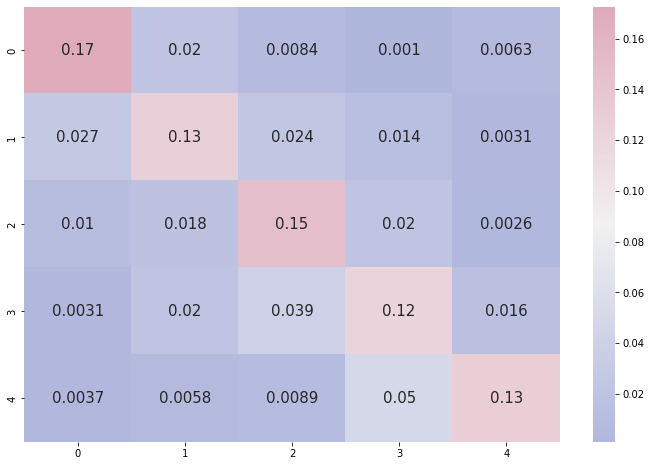

In [ ]:
cmap1 = sns.diverging_palette(260,-10,s=50, l=75, n=5, as_cmap=True)
plt.subplots(figsize=(12,8))
sns.heatmap(mnb_cm/np.sum(mnb_cm), cmap = cmap1, annot = True, annot_kws = {'size':15})

# Test

In [ ]:
mnb_model.predict(tfidf.transform(["بد نبود خوب بود"]))

array([1])